# The dynamic → quasi-static limit, measured with Sobolev norms

**Companion to [`problems/eta_convergence.py`](eta_convergence.py) and [`tools/norms.py`](../tools/norms.py).**
Every figure in this notebook is written to `output/report_figs/` in vector PDF and 200-dpi PNG,
ready to be dropped into the report.

---

## The question

`problems/dynamic.py` and `problems/thermal.py` each solve the *same* fracture problem twice:

* a **quasi-static** branch — rate-independent, no inertia, no viscosity: a sequence of energy
  minimisations, one per load level;
* a **dynamic** branch — Newmark-$\beta$ with inertia and the viscous terms $c_1,c_2,c_3$.

The two differ only through the **loading time-scale** $\eta$, which enters the imposed load as
$\tau=\eta t$. A large $\eta$ drives the same loading history fast and injects a lot of kinetic
energy; a small $\eta$ loads slowly. The physical expectation is

$$\boxed{\;\text{dynamic}(\eta)\;\longrightarrow\;\text{quasi-static}\qquad\text{as }\eta\to0\;}$$

and the point of this notebook is to **measure** that statement rather than assert it from a
figure — and to say *in what sense*, *how fast*, and *where it stops being true*.

> **Cost note.** The final dynamic time is stretched to $t_{\rm final}=1/\eta$ while
> `N_steps_dyn` is held fixed, so **each dynamic run costs the same** regardless of $\eta$ and a
> sweep is cheap. The flip side is that the time step $\Delta t=1/(\eta N_{\rm dyn})$ *grows* as
> $\eta$ shrinks; keep an eye on it if you push $\eta$ below $10^{-3}$.

## 1. Why not energies

The obvious comparison is between the two **total energies**. We tried that first, and it turned
out to measure the *bookkeeping* rather than the solutions. Two concrete defects, both verified
numerically:

**(a) The comparison is not symmetric.** The dynamic total recorded by the code is
$\mathcal K+\mathcal P_{el}+\mathcal P_f+\mathcal S$ and **excludes** the cumulative viscous
dissipation $\mathcal D$, while the quasi-static branch has no dissipation channel at all. The
dynamic branch therefore leaks energy out of the compared quantity and the quasi-static one does
not. That asymmetry alone produces a floor in any "gap" — and the crack event dissipates a
finite amount however slowly we load, so the floor does **not** vanish with $\eta$.

**(b) With a foundation the loading device keeps working.** In the mechanical test with
$\Lambda\neq0$ the broken fragments stay attached to the elastic foundation, so after the crack
the machine still pulls against the springs and the quasi-static *total energy rises*. Measured:
after the crack $\Delta\mathcal P_{el}=+1\cdot10^{-5}$, $\Delta\mathcal P_f=+2.65\cdot10^{-2}$,
$\Delta\mathcal S=+1.7\cdot10^{-4}$, total $+2.67\cdot10^{-2}$, against an external work
$\int F\,d\hat U=+2.65\cdot10^{-2}$ — they agree to $0.8\%$. The energy balance is *correct*; it
is the *comparison* that is contaminated, because it mixes stored energy with external work.

Setting $\Lambda=0$ removes (b) — with no foundation there is no load path after the crack, the
reaction drops to zero and the quasi-static total is flat (verified: $F_{\rm end}=5.6\cdot10^{-5}$,
$\Delta E=4.6\cdot10^{-5}$). It does nothing about (a).

**The cure for both is to stop comparing energies and compare the states.**

## 2. The right object: the state, and the space it lives in

Following the meeting of 27/07, the state of a gradient-damage model is the **pair**

$$y_t=(u_t,\alpha_t),$$

and the space is dictated by the energy itself. Requiring the energy to be finite,

$$\int_\Omega g(\alpha)\,|u'|^2+|u|^2+w(\alpha)+|\alpha'|^2\;<\;\infty,$$

forces **both** $u$ and $\alpha$ to be square integrable *together with their first derivatives*.
That is exactly the definition of the Sobolev space

$$H^1(\Omega)=\Big\{v:\ \Big(\int_\Omega|v|^2\Big)^{1/2}<\infty\ \ \text{and}\ \ \Big(\int_\Omega|v'|^2\Big)^{1/2}<\infty\Big\},$$

so $E(y)<\infty \Rightarrow (u,\alpha)\in H^1\times H^1$. The corresponding norms are

$$\|v\|_{L^2}=\Big(\int_\Omega|v|^2\Big)^{1/2},\qquad
\boxed{\ \|v\|_{H^1}=\Big(\int_\Omega|v|^2+\int_\Omega|v'|^2\Big)^{1/2}\ },\qquad
\|y\|^2=\|u\|^2_{H^1}+\|\alpha\|^2_{H^1}.$$

A norm is what makes "distance" meaningful: it satisfies the triangle inequality
$\|u+v\|\le\|u\|+\|v\|$, so $\|y_{\rm dyn}-y_{\rm qs}\|$ behaves like a genuine distance between
two solutions. (References: [Sobolev space](https://en.wikipedia.org/wiki/Sobolev_space),
[Norm](https://en.wikipedia.org/wiki/Norm_(mathematics)).)

**Why $H^1$ and not just $L^2$?** Because the gradient term $|\alpha'|^2$ is part of the model. Two
damage fields can be close in $L^2$ and yet describe different cracks if their *gradients* differ —
and it is the gradient that sets the width of the band. $H^1$ sees that; $L^2$ does not.

## 3. Exactness, and why norm equivalence matters

### The integrals are exact, not quadrature

All fields here are **P1** (piecewise linear). For such a field every integral above can be done in
closed form, so **no quadrature error enters the measurement**. On an element of length $h$ with
nodal values $v_i,v_j$:

$$\int_e v^2\,dx=\frac{h}{3}\big(v_i^2+v_iv_j+v_j^2\big),\qquad
\int_e (v')^2\,dx=\frac{(v_j-v_i)^2}{h},$$

the second because the derivative of a linear interpolant is constant on the element. This is what
[`tools/norms.py`](../tools/norms.py) implements. The cell below checks both against analytic
values on a deliberately **non-uniform** mesh.

> **A trap worth knowing.** dolfinx numbers degrees of freedom in *solver* order, which is not
> left-to-right along the bar. Every formula above assumes the nodes are sorted, so
> `tools.norms.sort_dofs` builds that permutation once and it is applied before any norm is taken.

### Norm equivalence

Two norms are **equivalent** when there is a constant $C>0$ with

$$C\,\|v\|_1\;\le\;\|v\|_2\;\le\;\tfrac1C\,\|v\|_1 .$$

On a fixed finite-dimensional space (which a finite-element space is) *all* norms are equivalent.
The consequence for us is a demand on the study: **the conclusion must not depend on which norm we
picked**. So instead of choosing one and hoping, the study reports the whole family — $L^2$ and
$H^1$ of $u$, of $\alpha$, and of the state $y$ — and the figure overlays them. If they fall
together, the result is a property of the solutions; if they did not, it would be a property of our
choice.

In [1]:
import sys
from pathlib import Path
import numpy as np

# autoreload: edits to tools/ and problems/ take effect without a kernel restart

ROOT = Path.cwd().resolve()
if ROOT.name == "problems":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

from tools.norms import l2_norm_sq, h1_semi_norm_sq, h1_norm, state_norm

# A deliberately NON-uniform mesh, so a lucky cancellation cannot hide an error.
x = np.sort(np.concatenate([np.linspace(0, 1, 9), [0.13, 0.44, 0.79]]))

print("check the P1 formulas against exact analytic values")
print(f"{'field':>12} {'quantity':>14} {'computed':>14} {'exact':>10}")
for name, v, l2x, h1x in (("v = x",  x,            1/3, 1.0),
                          ("v = 1",  np.ones_like(x), 1.0, 0.0),
                          ("v = 2x", 2*x,          4/3, 4.0)):
    print(f"{name:>12} {'int v^2':>14} {l2_norm_sq(x, v):14.10f} {l2x:10.4f}")
    print(f"{'':>12} {'int (v)^2':>14} {h1_semi_norm_sq(x, v):14.10f} {h1x:10.4f}")
assert abs(l2_norm_sq(x, x) - 1/3) < 1e-12 and abs(h1_semi_norm_sq(x, x) - 1.0) < 1e-12
print("\nthe P1 norms are EXACT (machine precision) on a non-uniform mesh")

# and the triangle inequality, which is what makes them a distance
rng = np.random.default_rng(0)
for _ in range(3):
    u, v = rng.normal(size=x.size), rng.normal(size=x.size)
    assert h1_norm(x, u + v) <= h1_norm(x, u) + h1_norm(x, v) + 1e-12
print("triangle inequality holds for the H1 norm  ->  it is a genuine distance")

check the P1 formulas against exact analytic values
       field       quantity       computed      exact
       v = x        int v^2   0.3333333333     0.3333
                  int (v)^2   1.0000000000     1.0000
       v = 1        int v^2   1.0000000000     1.0000
                  int (v)^2   0.0000000000     0.0000
      v = 2x        int v^2   1.3333333333     1.3333
                  int (v)^2   4.0000000000     4.0000

the P1 norms are EXACT (machine precision) on a non-uniform mesh
triangle inequality holds for the H1 norm  ->  it is a genuine distance


## 4. Method

Both branches are solved **on the same mesh** with the same material — only $\eta$ differs — so
their nodal vectors are directly comparable and no *spatial* interpolation is needed. What does
differ is the set of **load levels** each branch visits (the quasi-static ramp uses `N_steps_qs`
steps, the dynamic one `N_steps_dyn`). So:

1. `run_problem` is given a `field_recorder` callback, which stores $(\text{load},u,\alpha)$ at
   every converged step of both branches. This hook is the only change made to the two problem
   files, and it is inert when not used;
2. every field history is interpolated **in the load** (node by node) onto one common grid;
3. the distances are taken there, giving a curve $\|y_{\rm dyn}-y_{\rm qs}\|$ *along the loading
   path*, one per $\eta$;
4. each curve is reduced to a single number, normalised by $\max\|y_{\rm qs}\|$.

### Which single number — and a trap

The obvious reduction is the worst case over the whole path. **That is the wrong number here.**
The state jumps discontinuously at the crack, and a difference of a fraction of a load step in
*when* or *where* it jumps costs an $O(1)$ distance no matter how small $\eta$ is. Averaging that
together with the smooth elastic part hides everything.

So the path is split at the crack, and the study reports the elastic part separately. The crack
load is detected as the largest jump of $\|y\|$ — **upward**, not downward: when the bar breaks,
the damage band raises $\|\alpha\|_{H^1}$ and the displacement develops a steep gradient across the
band, so the state norm *grows*. And the split uses the **earliest** crack over the quasi-static
branch *and* every dynamic one, because if a single branch cracks early the "elastic" window is
contaminated for all of them.

## 5. A non-uniqueness the norm exposes and the energy hides

The first run of this study gave a distance that **grew** as $\eta$ was reduced. That is not a bug
— it is a real property of the problem, and finding it is an argument for the norm method.

A perfectly homogeneous bar with $\Lambda=0$ is **translation invariant**: every crack position
costs exactly the same energy. The evolution problem therefore has **no unique solution**, and the
two branches localise wherever their own discretisation pushes them. Measured, with no
imperfection:

| $\eta$ | quasi-static crack at | dynamic crack(s) at |
|---|---|---|
| 0.3 | 0.5 | 0.913 |
| 0.1 | 0.5 | 0.093 and 0.887 |
| 0.03 | 0.5 | 0.073 and 0.62 |
| 0.01 | 0.5 | 0.36 |

The field distance is then dominated by *where* the crack is, and cannot converge. **The energy is
completely blind to this**, because translating a crack does not change any energy — which is
precisely why the energy-based study looked healthier than it was.

**The fix** is the standard one: break the symmetry with a small imperfection. `run_eta_study`
seeds a Gaussian pre-damage bump, `defect=(x0, width, alpha0)`, as the initial irreversibility
bound of *both* branches (`tools.helpers.defect_seed`). Pass `defect=None` to reproduce the
pathological case.

And the way it fixes it is itself informative: the imperfection only wins **once the loading is
slow enough**. At $\eta=0.3$ the dynamic branch still cracks at $0.913$ — inertia beats the defect;
at $\eta=0.03$ it cracks at $0.507$ against the quasi-static $0.5$. That crossover is a
**bifurcation** phenomenon, of exactly the kind the stability literature in `Articles/` is about
(see `secondary_theory.ipynb` and the report guide).

[eta norm | mechanical] (1/7) eta=0.5 ...
[eta norm | mechanical] (2/7) eta=0.2 ...
[eta norm | mechanical] (3/7) eta=0.1 ...
[eta norm | mechanical] (4/7) eta=0.05 ...
[eta norm | mechanical] (5/7) eta=0.02 ...
[eta norm | mechanical] (6/7) eta=0.01 ...
[eta norm | mechanical] (7/7) eta=0.005 ...

[eta norm | mechanical] crack event at load = 0.5800
relative distance to the quasi-static state, BEFORE the crack (sup over the elastic part of the path):
      eta        u_L2       u_H1       a_L2       a_H1       y_H1
      0.5   7.675e-02  2.132e-02  3.228e-01  2.098e-01  1.162e-01
      0.2   2.496e-02  7.400e-03  0.000e+00  0.000e+00  6.170e-03
      0.1   1.222e-02  3.973e-03  0.000e+00  0.000e+00  3.312e-03
     0.05   7.190e-03  2.295e-03  0.000e+00  0.000e+00  1.913e-03
     0.02   4.432e-03  1.441e-03  0.000e+00  0.000e+00  1.202e-03
     0.01   2.670e-03  8.159e-04  0.000e+00  0.000e+00  6.802e-04
    0.005   1.353e-03  4.038e-04  0.000e+00  0.000e+00  3.367e-04
observed order i

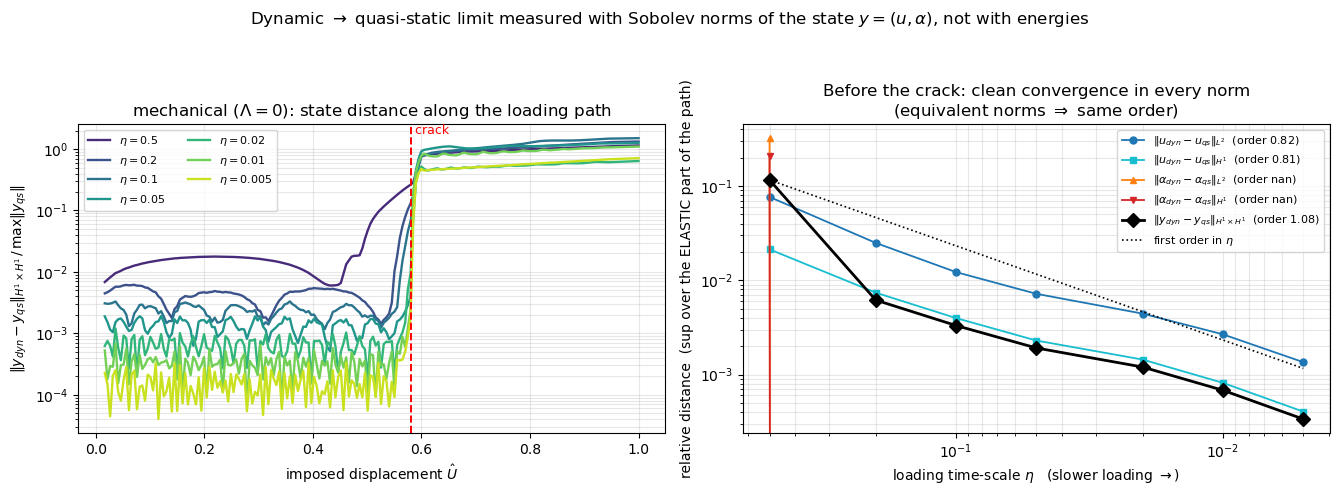


crack detected at load = 0.58

order of convergence in eta, over the ELASTIC part of the path:
     u_L2 : 0.82
     u_H1 : 0.81
     a_L2 : exactly 0 (AT1 elastic phase: alpha == 0 in both branches)
     a_H1 : exactly 0 (AT1 elastic phase: alpha == 0 in both branches)
     y_H1 : 1.08


In [2]:
from problems.eta_convergence import run_eta_study
%matplotlib inline

# Mechanical, Lambda = 0 (no foundation -> no load path after the crack).
# This runs the full QS + dynamic FEM once per eta: a few minutes in total.
study_mech = run_eta_study("mechanical",
                           etas=[0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005])

print("\ncrack detected at load =", round(study_mech["load_crack"], 4))
print("\norder of convergence in eta, over the ELASTIC part of the path:")
for m in study_mech["metrics"]:
    o = study_mech["order"][m]
    tag = "exactly 0 (AT1 elastic phase: alpha == 0 in both branches)" \
          if np.isnan(o) else f"{o:.2f}"
    print(f"   {m:>6} : {tag}")

### Reading the result

**Left panel — along the loading path.** Before the crack the two branches are solving the same
smooth problem and the only difference is inertia: the distance falls by orders of magnitude as
$\eta$ is reduced. At the crack (red line) every curve jumps to $O(1)$ and stays there.

**Right panel — the elastic regime.** All the norms fall together with the same slope. Two things
to take from it:

* the fitted order is close to **1**: the dynamic state approaches the quasi-static one *linearly*
  in the loading time-scale, $\|y_{\rm dyn}-y_{\rm qs}\|=O(\eta)$;
* they agree with each other, which is norm equivalence made visible — the conclusion is not an
  artefact of the norm we chose.

**A detail that is physics, not a failure.** For AT1 the damage distance is *exactly zero*
throughout the elastic phase, because $\alpha\equiv0$ in **both** branches until the threshold is
reached — AT1 has a genuine elastic phase. There is no slope to fit through zeros, so the study
flags it rather than reporting a meaningless number. With AT2 (which damages from the first
increment) that entry would be finite instead.

**What the $O(1)$ post-crack plateau means.** It is not numerical noise, and it does not go away
with refinement: the quasi-static branch jumps *instantaneously* at the critical load, while the
dynamic branch has to accelerate, radiate and dissipate to get to the same place. The limit
$\eta\to0$ is **not uniform across the crack event** — which is exactly the statement that the
crack is an instability, and the reason the stability/bifurcation analysis of the two papers is the
right tool there rather than a convergence rate.

[eta norm | thermal] (1/7) eta=0.5 ...
[eta norm | thermal] (2/7) eta=0.2 ...
[eta norm | thermal] (3/7) eta=0.1 ...
[eta norm | thermal] (4/7) eta=0.05 ...
[eta norm | thermal] (5/7) eta=0.02 ...
[eta norm | thermal] (6/7) eta=0.01 ...
[eta norm | thermal] (7/7) eta=0.005 ...

[eta norm | thermal] crack event at load = 1.6658
relative distance to the quasi-static state, BEFORE the crack (sup over the elastic part of the path):
      eta        u_L2       u_H1       a_L2       a_H1       y_H1
      0.5   1.624e-01  1.866e-02  0.000e+00  0.000e+00  1.645e-02
      0.2   5.277e-02  6.061e-03  0.000e+00  0.000e+00  5.345e-03
      0.1   2.385e-02  2.734e-03  0.000e+00  0.000e+00  2.411e-03
     0.05   1.104e-02  1.266e-03  0.000e+00  0.000e+00  1.116e-03
     0.02   4.144e-03  4.785e-04  0.000e+00  0.000e+00  4.219e-04
     0.01   2.006e-03  2.314e-04  0.000e+00  0.000e+00  2.041e-04
    0.005   1.106e-03  1.267e-04  0.000e+00  0.000e+00  1.117e-04
observed order in eta: u_L2=1.09  u_H1=1

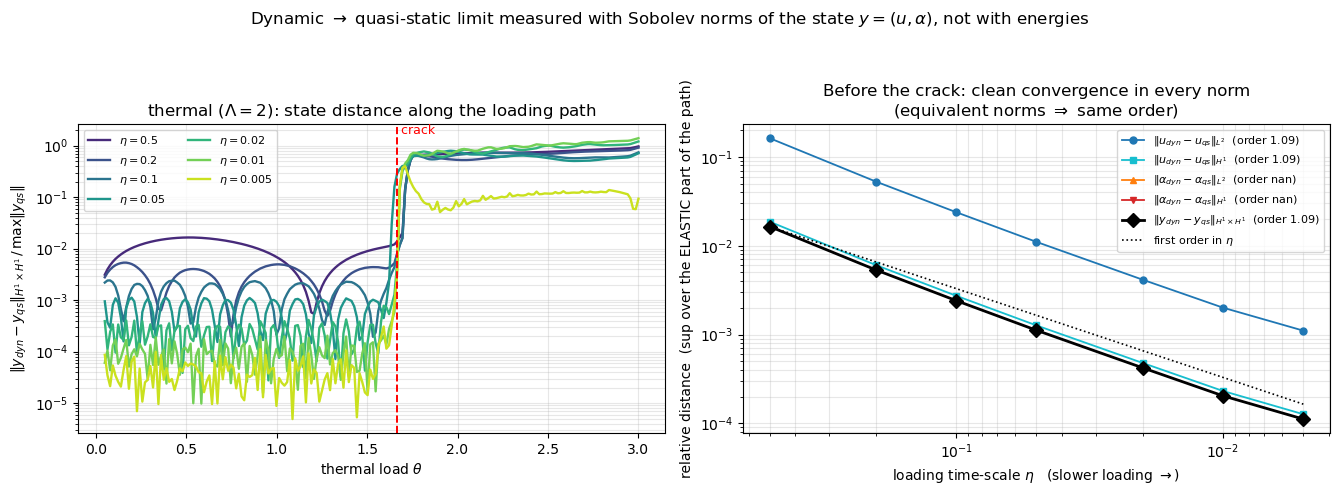


crack detected at load = 1.6658

order of convergence in eta (elastic part):
     u_L2 : 1.09
     u_H1 : 1.09
     a_L2 : exactly 0 (elastic phase)
     a_H1 : exactly 0 (elastic phase)
     y_H1 : 1.09


In [3]:
# The thermal problem keeps its foundation (Lambda = 2): it is what makes the
# fragmentation periodic in the first place, so it is not switched off here.
study_therm = run_eta_study("thermal",
                            etas=[0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005])

print("\ncrack detected at load =", round(study_therm["load_crack"], 4))
print("\norder of convergence in eta (elastic part):")
for m in study_therm["metrics"]:
    o = study_therm["order"][m]
    print(f"   {m:>6} : " + ("exactly 0 (elastic phase)" if np.isnan(o) else f"{o:.2f}"))

## 6. What to put in the report

**The claim.** *Below the crack load the dynamic solution converges to the quasi-static one at
first order in the loading time-scale, in every Sobolev norm of the state; at and beyond the crack
it does not converge at all, because the crack is a discontinuous, unstable event.*

**The evidence, in the order it should be presented.**

1. the state and the space: $y=(u,\alpha)\in H^1\times H^1$, forced by finiteness of the energy;
2. the norms, and the fact that they are computed exactly for P1 fields;
3. norm equivalence, and the resulting requirement that all of them agree — then the figure showing
   that they do;
4. the two regimes, elastic and post-crack, and why they must be reported separately;
5. the non-uniqueness experiment (crack site table above) as the reason a small imperfection is
   part of the protocol — and as the first appearance of bifurcation in this work.

**Figures.** `output/report_figs/eta_norm_mechanical.{pdf,png}` and
`eta_norm_thermal.{pdf,png}` (PDF is vector — that is the one to `\includegraphics`). The raw
curves are in `output/eta_norm_<physics>.npz`, so the figures can be restyled for the report
without re-running any FEM.

**Honest limitations to state.**

* the time step grows as $\Delta t=1/(\eta N_{\rm dyn})$, so very small $\eta$ eventually
  under-resolves the wave transit; the range used here stays clear of that, but it should be said;
* the fitted order (0.8–1.1 depending on the norm) is an *observed* rate on one problem, not a
  theorem;
* the post-crack plateau is a property of the model — a rate-independent branch that jumps versus a
  dynamic branch that cannot — and not something to be fixed by refinement.